In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("Academic_Performance_Dataset.csv")

print("\nFirst 5 Records:\n")
print(df.head())


First 5 Records:

   Student_ID  Student_Name  Gender   Age  Math_Score  Science_Score  \
0           1  Aarav Sharma    Male  16.0        78.0           72.0   
1           2    Diya Patel  Female  17.0         NaN           60.0   
2           3   Rohan Verma    Male  18.0        88.0           75.0   
3           4  Ananya Singh  Female  16.0        54.0           58.0   
4           5  Vihaan Gupta     NaN   NaN        91.0           84.0   

   English_Score  Attendance_Percentage  Study_Hours  
0           81.0                   88.0          4.0  
1           74.0                   92.0          NaN  
2            NaN                   95.0          6.0  
3           69.0                   80.0          2.0  
4           89.0                   97.0          7.0  


In [18]:
print("\nMissing Values in Each Column:\n")
print(df.isnull().sum())


Missing Values in Each Column:

Student_ID               0
Student_Name             0
Gender                   1
Age                      4
Math_Score               2
Science_Score            2
English_Score            2
Attendance_Percentage    1
Study_Hours              4
dtype: int64


In [ ]:

# 1. Gender (Categorical → Mode Imputation)
df["Gender"].fillna(df["Gender"].mode()[0], inplace=True)

# 2. Age (Numeric → Median Imputation)
df["Age"].fillna(df["Age"].median(), inplace=True)

# 3. Scores & Study Hours (Numeric → Mean Imputation)
numeric_cols = ["Math_Score","Science_Score",
                "English_Score","Attendance_Percentage",
                "Study_Hours"]


In [20]:
for col in numeric_cols:
    df[col].fillna(df[col].mean(), inplace=True)

print("\nMissing Values After Cleaning:\n")
print(df.isnull().sum())



Missing Values After Cleaning:

Student_ID               0
Student_Name             0
Gender                   0
Age                      0
Math_Score               0
Science_Score            0
English_Score            0
Attendance_Percentage    0
Study_Hours              0
dtype: int64


In [ ]:

df["Gender"] = df["Gender"].replace({"M": "Male", "F": "Female"})


df.loc[df["Attendance_Percentage"] > 100, "Attendance_Percentage"] = 100
df.loc[df["Attendance_Percentage"] < 0, "Attendance_Percentage"] = 0

df.loc[df["Age"] <= 0, "Age"] = df["Age"].median()

print("\nData cleaned for inconsistencies.")



Data cleaned for inconsistencies.



Outliers treated using IQR Capping Method.


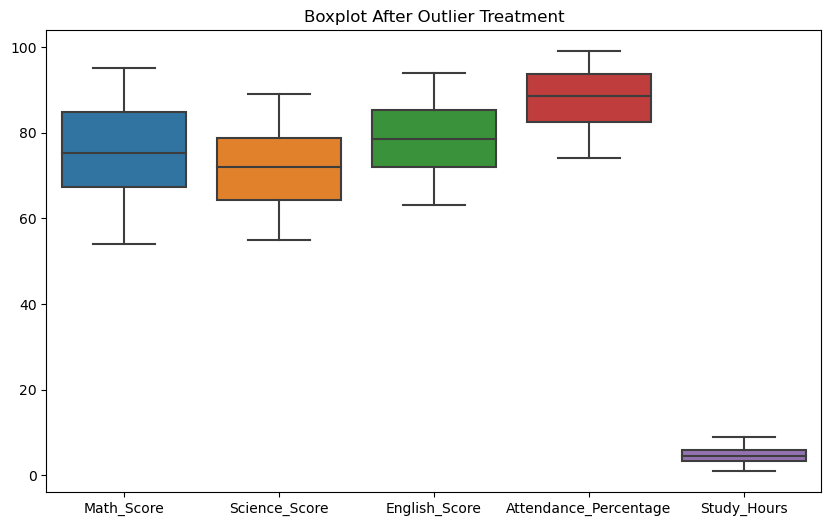

In [ ]:

def treat_outliers_iqr(column):
    Q1 = column.quantile(0.25)
    Q3 = column.quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    return np.where(column > upper, upper,
           np.where(column < lower, lower, column))

for col in numeric_cols:
    df[col] = treat_outliers_iqr(df[col])

print("\nOutliers treated using IQR Capping Method.")

plt.figure(figsize=(10,6))
sns.boxplot(data=df[numeric_cols])
plt.title("Boxplot After Outlier Treatment")
plt.show()




In [26]:
# Check skewness before transformation
print("\nSkewness Before Transformation:")
print(df["Study_Hours"].skew())



Skewness Before Transformation:
0.30638182177278345


In [27]:

# Apply Log Transformation to reduce skewness
df["Study_Hours_Log"] = np.log1p(df["Study_Hours"])

print("\nSkewness After Log Transformation:")
print(df["Study_Hours_Log"].skew())



Skewness After Log Transformation:
-0.546151373266212


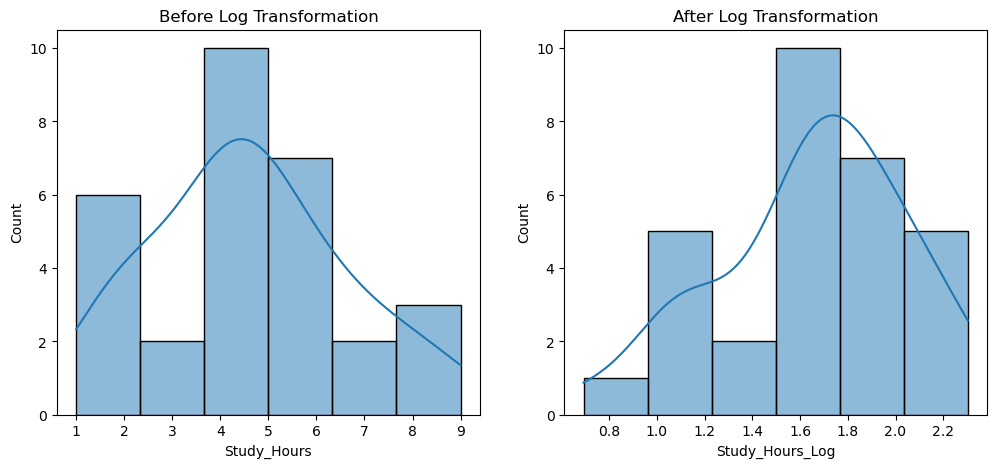

In [28]:

# Compare distributions
fig, ax = plt.subplots(1,2, figsize=(12,5))

sns.histplot(df["Study_Hours"], kde=True, ax=ax[0])
ax[0].set_title("Before Log Transformation")

sns.histplot(df["Study_Hours_Log"], kde=True, ax=ax[1])
ax[1].set_title("After Log Transformation")

plt.show()

In [29]:
print(df.head())

   Student_ID  Student_Name  Gender   Age  Math_Score  Science_Score  \
0           1  Aarav Sharma    Male  16.0   78.000000           72.0   
1           2    Diya Patel  Female  17.0   75.321429           60.0   
2           3   Rohan Verma    Male  18.0   88.000000           75.0   
3           4  Ananya Singh  Female  16.0   54.000000           58.0   
4           5  Vihaan Gupta  Female  17.0   91.000000           84.0   

   English_Score  Attendance_Percentage  Study_Hours  Study_Hours_Log  
0      81.000000                   88.0     4.000000         1.609438  
1      74.000000                   92.0     4.576923         1.718637  
2      78.428571                   95.0     6.000000         1.945910  
3      69.000000                   80.0     2.000000         1.098612  
4      89.000000                   97.0     7.000000         2.079442  
